In [1]:
import pandas as pd
import numpy as np
import sklearn

In [2]:
DADOS = "../dados/Mall_Customers.csv"

df = pd.read_csv(DADOS)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df)

profile.to_file("../reports/eda_supermercado.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 105.13it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### Visão Geral dos Dados

Na etapa de *overview*, é possível observar que o conjunto de dados apresenta boa qualidade, sem valores ausentes ou registros duplicados.  
O dataset é composto por quatro variáveis numéricas e uma variável categórica, referente ao gênero dos clientes (Masculino e Feminino).

### Análise das Variáveis

#### Idade (Age)
A idade dos clientes varia entre 18 e 70 anos. Nota-se uma maior concentração de indivíduos na faixa etária entre 30 e 40 anos, o que sugere que esse pode ser o perfil predominante de clientes presentes na base de dados.

#### Renda Anual (Annual Income - K$)
A renda anual apresenta maior concentração entre 60 e 75. Também é possível identificar a presença de alguns valores extremos (outliers), principalmente acima de 105, que representam clientes com rendas significativamente superiores à média.

#### Pontuação de Gastos (Spending Score)
A pontuação de gastos concentra-se majoritariamente entre os valores 40 e 60, indicando um comportamento de consumo intermediário para a maior parte dos clientes analisados.

### Análise de Correlação

#### Spending Score (1-100) vs Age
Observa-se uma tendência de redução da pontuação de gastos à medida que a idade aumenta. Clientes mais jovens, especialmente até cerca de 40 anos, tendem a apresentar pontuações de gastos mais elevadas, enquanto clientes mais velhos demonstram um comportamento de consumo mais conservador.

#### Annual Income (k$) vs Age
A análise entre renda anual e idade indica que as maiores rendas estão concentradas na faixa etária entre 30 e 50 anos, sugerindo um período de maior estabilidade financeira dentro da base analisada.

#### Spending Score (1-100) vs Annual Income (k$)
A relação entre pontuação de gastos e renda anual revela um padrão interessante: é possível identificar visualmente a formação de aproximadamente cinco grupos distintos de clientes. Esse comportamento sugere fortemente a existência de diferentes perfis de consumo, reforçando o potencial de aplicação de técnicas de segmentação, como algoritmos de clusterização.


In [4]:
df_analise = df.copy()
df_analise = df_analise.drop("CustomerID", axis=1)

df_analise.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


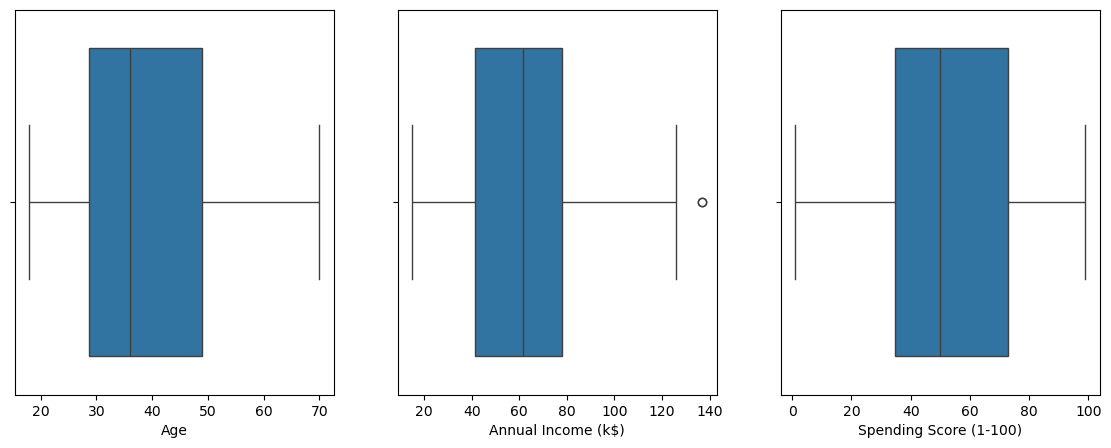

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(14, 5))

for ax, col in zip(axs, df_analise.select_dtypes("number")):
    sns.boxplot(data=df_analise, x=col, ax=ax)

plt.show()

### Análise Exploratória dos Dados
#### Idade (AGE)
A maior concentração de clientes está aproximadamente entre 30 e 50 anos. A mediana encontra-se próxima dos 40 anos, indicando um público majoritariamente adulto.
A distribuição é relativamente equilibrada, sem presença significativa de outliers.

#### Renda Anual (Annual Income)
A maior parte dos clientes possui renda entre aproximadamente 40k e 80k dólares anuais. A mediana está próxima de 60k, indicando um poder aquisitivo médio.
Observa-se a presença de outliers de alta renda, sugerindo alguns clientes com renda significativamente acima da média.

#### Pontuação de Gasto (Spending Score)
A pontuação varia amplamente entre 0 e 100, mostrando diferentes perfis de comportamento de consumo. A mediana está próxima de 50, indicando um comportamento médio de gasto.
A dispersão é relativamente alta, sugerindo clientes tanto conservadores quanto altamente consumidores.

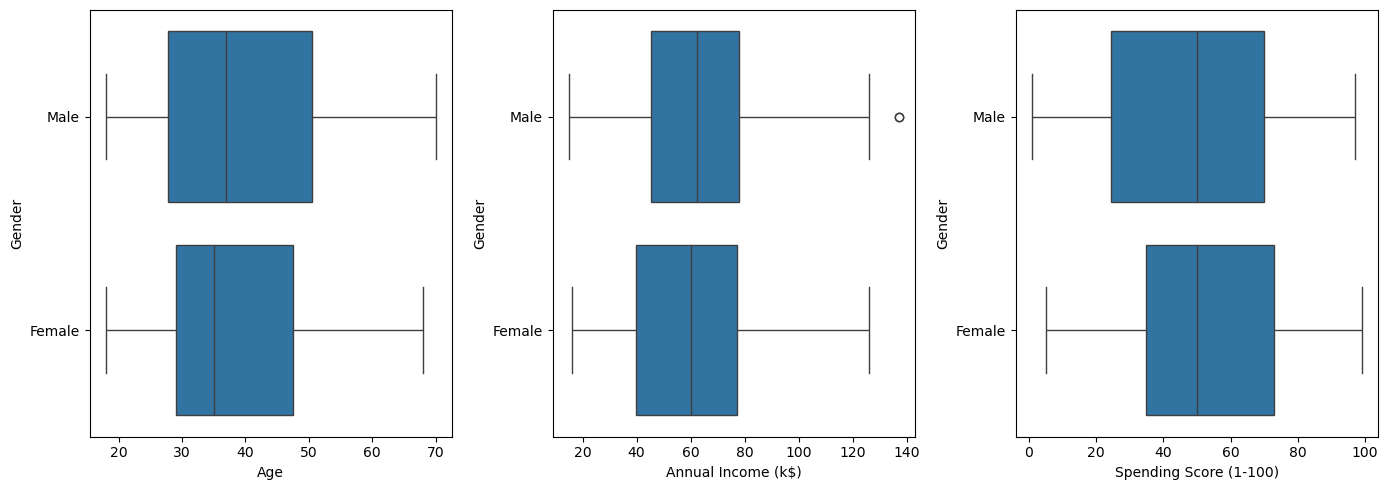

In [7]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(14, 5), tight_layout=True)

for ax, col in zip(axs, df_analise.select_dtypes("number")):
    sns.boxplot(data=df_analise, x=col, y="Gender", ax=ax)

plt.show()

### Análise Comparativa por Gênero
#### Idade por Gênero
Homens e mulheres apresentam faixas etárias muito semelhantes, concentradas principalmente entre 30 e 50 anos.

#### Renda Anual por Gênero
A maior concentração de renda, tanto para homens quanto para mulheres, está entre 40k e 80k dólares anuais. Observa-se a presença de outliers de alta renda, principalmente no grupo masculino, sugerindo alguns clientes com rendas significativamente mais altas.

#### Spending Score por Gênero
Ambos os gêneros apresentam uma ampla variação de pontuação, cobrindo praticamente todo o intervalo de 0 a 100.
Mulheres apresentam uma leve tendência a valores um pouco mais elevados de Spending Score, sugerindo maior propensão ao consumo em alguns casos.

In [8]:
with pd.option_context("display.float_format", "{:.3f}".format):
    display(df_analise.corr(numeric_only=True, method="spearman"))

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000,0.020,-0.345
Annual Income (k$),0.020,1.000,0.008
Spending Score (1-100),-0.345,0.008,1.000


In [18]:
sns.pairplot(df_analise, diag_kind="kde");

In [19]:
sns.pairplot(df_analise, diag_kind="kde", hue="Gender");

In [20]:
df_analise.to_csv("../dados/Mall_Customers_no_CustomerID.csv", index=False)